# Single-Pair Deep Analysis: PF00096 / PF00397 at Overlap 49 nt

**Goal:** Determine whether any single MC trial can produce a nucleotide sequence where *both* proteins land within 1 standard deviation of their natural DCA energy distributions.

- **Pair:** PF00096 (23 aa) / PF00397 (28 aa)
- **Overlap:** 49 nt (Reading Frame +1)
- **Trials:** 500 independent MC runs, 250k iterations each

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from thesis_plots import *
apply_style()

# --- IMPORTS & DATA LOADING ---
import numpy as np
import matplotlib.pyplot as plt

import os, sys, json
from tqdm.auto import tqdm
sys.path.append(os.getcwd())
import overlappingGenes as og

# --- Load DCA parameters ---
BASE_DIR = "bmDCA"
PF1, PF2 = "PF00096", "PF00397"
OVERLAP = 49

J1, h1 = og.extract_params(os.path.join(BASE_DIR, PF1, f"{PF1}_params.dat"))
J2, h2 = og.extract_params(os.path.join(BASE_DIR, PF2, f"{PF2}_params.dat"))
params1, params2 = [J1, h1], [J2, h2]

len1 = len(h1) // 21
len2 = len(h2) // 21

# --- Load natural energy statistics ---
nat_energies1 = og.load_natural_energies(os.path.join(BASE_DIR, PF1, f"{PF1}_naturalenergies.txt"))
nat_energies2 = og.load_natural_energies(os.path.join(BASE_DIR, PF2, f"{PF2}_naturalenergies.txt"))
nat_mean1, nat_std1 = np.mean(nat_energies1), np.std(nat_energies1)
nat_mean2, nat_std2 = np.mean(nat_energies2), np.std(nat_energies2)

# --- Load optimal temperatures ---
with open("optimal_temperatures.json") as f:
    opt_temps = json.load(f)
T1, T2 = opt_temps[PF1], opt_temps[PF2]

# --- Summary ---
print(f"Protein 1: {PF1}  ({len1} aa)   T = {T1:.4f}")
print(f"Protein 2: {PF2}  ({len2} aa)   T = {T2:.4f}")
print(f"Overlap:   {OVERLAP} nt  (Frame +{OVERLAP % 3})")
print(f"Max overlap: {min(len1, len2) * 3 - 6} nt")
print(f"\nNatural energy {PF1}: {nat_mean1:.2f} +/- {nat_std1:.2f}")
print(f"Natural energy {PF2}: {nat_mean2:.2f} +/- {nat_std2:.2f}")

Protein 1: PF00096  (23 aa)   T = 0.8543
Protein 2: PF00397  (28 aa)   T = 0.8532
Overlap:   49 nt  (Frame +1)
Max overlap: 63 nt

Natural energy PF00096: 16.44 +/- 5.23
Natural energy PF00397: 34.45 +/- 7.29


In [8]:
# --- RUN TRIALS ---
N_TRIALS = 500
ITERATIONS = 250_000
WHENTOSAVE = 0.01

final_e1, final_e2 = [], []
best_e1, best_e2 = [], []
all_hist1, all_hist2 = [], []

for i in tqdm(range(N_TRIALS)):
    init_seq = og.initial_seq_no_stops(len1, len2, OVERLAP, quiet=True)

    result = og.overlapped_sequence_generator_int(
        params1, params2, init_seq,
        T1=T1, T2=T2,
        numberofiterations=ITERATIONS,
        whentosave=WHENTOSAVE,
        quiet=True,
        nat_mean1=nat_mean1, nat_mean2=nat_mean2,
        nat_std1=nat_std1, nat_std2=nat_std2,
        use_z_score=True
    )

    final_e1.append(result[4][0])
    final_e2.append(result[4][1])
    best_e1.append(result[5][0])
    best_e2.append(result[5][1])
    all_hist1.append(result[2])
    all_hist2.append(result[3])

final_e1 = np.array(final_e1)
final_e2 = np.array(final_e2)
best_e1 = np.array(best_e1)
best_e2 = np.array(best_e2)

# --- Convert to z-scores ---
z_final_1 = (final_e1 - nat_mean1) / nat_std1
z_final_2 = (final_e2 - nat_mean2) / nat_std2
z_best_1 = (best_e1 - nat_mean1) / nat_std1
z_best_2 = (best_e2 - nat_mean2) / nat_std2

# Convert energy histories to z-scores
z_hist1 = [(h - nat_mean1) / nat_std1 for h in all_hist1]
z_hist2 = [(h - nat_mean2) / nat_std2 for h in all_hist2]

# --- Convergence summary (|z| < 1 means within 1 std of natural) ---
conv_final_1 = np.sum(np.abs(z_final_1) < 1)
conv_final_2 = np.sum(np.abs(z_final_2) < 1)
conv_final_both = np.sum((np.abs(z_final_1) < 1) & (np.abs(z_final_2) < 1))

conv_best_1 = np.sum(np.abs(z_best_1) < 1)
conv_best_2 = np.sum(np.abs(z_best_2) < 1)
conv_best_both = np.sum((np.abs(z_best_1) < 1) & (np.abs(z_best_2) < 1))

print(f"\n{'='*60}")
print(f"CONVERGENCE SUMMARY ({N_TRIALS} trials)")
print(f"{'='*60}")
print(f"\nFinal z-scores within |z| < 1:")
print(f"  {PF1}: {conv_final_1}/{N_TRIALS} ({100*conv_final_1/N_TRIALS:.1f}%)")
print(f"  {PF2}: {conv_final_2}/{N_TRIALS} ({100*conv_final_2/N_TRIALS:.1f}%)")
print(f"  Both:    {conv_final_both}/{N_TRIALS} ({100*conv_final_both/N_TRIALS:.1f}%)")
print(f"\nBest z-scores (closest approach) within |z| < 1:")
print(f"  {PF1}: {conv_best_1}/{N_TRIALS} ({100*conv_best_1/N_TRIALS:.1f}%)")
print(f"  {PF2}: {conv_best_2}/{N_TRIALS} ({100*conv_best_2/N_TRIALS:.1f}%)")
print(f"  Both:    {conv_best_both}/{N_TRIALS} ({100*conv_best_both/N_TRIALS:.1f}%)")
print(f"\nMin |z| reached:")
print(f"  {PF1}: {np.abs(z_best_1).min():.3f}  (median {np.median(np.abs(z_best_1)):.3f})")
print(f"  {PF2}: {np.abs(z_best_2).min():.3f}  (median {np.median(np.abs(z_best_2)):.3f})")

  0%|          | 0/500 [00:00<?, ?it/s]

SystemError: CPUDispatcher(<function overlapped_sequence_generator_int at 0x328cb9800>) returned a result with an exception set

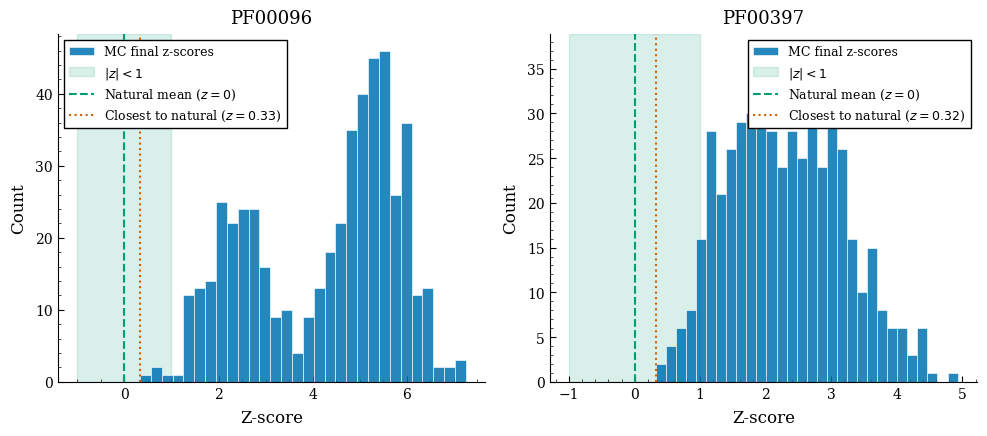

Saved: single_pair_final_zscore_dist_PF00096_PF00397.png


In [ ]:
# --- DISTRIBUTION OF FINAL Z-SCORES ---


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, z_scores, pf_name in [
    (ax1, z_final_1, PF1),
    (ax2, z_final_2, PF2),
]:
    ax.hist(z_scores, bins=30, color=BLUE, edgecolor='white',
            linewidth=0.5, alpha=0.85, label='MC final z-scores', zorder=2)

    # Convergence band: |z| < 1
    ax.axvspan(-1, 1, color=GREEN, alpha=0.15,
               label=r'$|z| < 1$', zorder=1)
    ax.axvline(0, color=GREEN, linewidth=1.5, linestyle='--',
               label='Natural mean ($z = 0$)', zorder=3)

    # Closest to z=0
    closest_idx = np.argmin(np.abs(z_scores))
    closest_val = z_scores[closest_idx]
    ax.axvline(closest_val, color=VERMILLION, linewidth=1.5, linestyle=':',
               label=f'Closest to natural ($z = {closest_val:.2f}$)', zorder=3)

    ax.set_xlabel('Z-score')
    ax.set_ylabel('Count')
    ax.set_title(pf_name, fontsize=13)
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('single_pair_final_zscore_dist_PF00096_PF00397.png')
plt.show()
print("Saved: single_pair_final_zscore_dist_PF00096_PF00397.png")

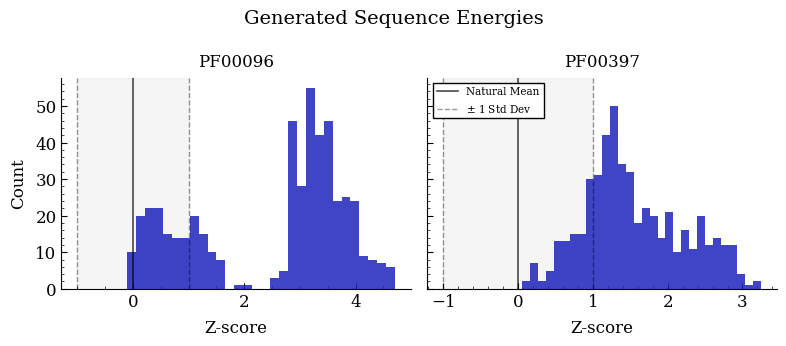

Saved: single_pair_best_zscore_dist_PF00096_PF00397.png


In [40]:
# --- DISTRIBUTION OF BEST (MINIMUM-DISTANCE) Z-SCORES ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5),sharey=True)

for i, (ax, z_scores, pf_name) in enumerate([
    (ax1, z_best_1, PF1),
    (ax2, z_best_2, PF2),
]):
    ax.hist(z_scores, bins=30,
            linewidth=0.5, alpha=0.85, zorder=2)

    ax.axvspan(-1, 1, color='grey', alpha=0.08, zorder=1)
    ax.axvline(0, color='black', linestyle='-', lw=1.2, alpha=0.7, label='Natural Mean', zorder=3)
    ax.axvline(-1, color='black', linestyle='--', lw=1, alpha=0.4, label=r'$\pm$ 1 Std Dev', zorder=3)
    ax.axvline(1, color='black', linestyle='--', lw=1, alpha=0.4, zorder=3)

    # Count within band
    n_in = np.sum(np.abs(z_scores) < 1)
    

    ax.set_xlabel('Z-score')
    if i ==0:

        ax.set_ylabel('Count')
    ax.set_title(pf_name)
    ax.tick_params(labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend only on the first subplot
    if i == 1:
        ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1, fontsize=7.5,loc='upper left')
fig.suptitle('Generated Sequence Energies')
plt.tight_layout()
plt.savefig('single_pair_best_zscore_dist_PF00096_PF00397.png')
plt.show()
print("Saved: single_pair_best_zscore_dist_PF00096_PF00397.png")

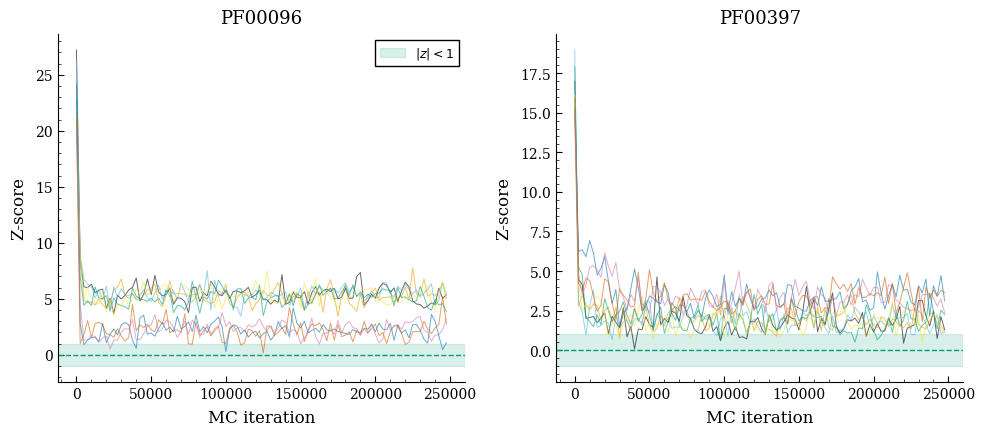

Saved: single_pair_zscore_trajectories_PF00096_PF00397.png


In [ ]:
# --- Z-SCORE TRAJECTORIES (10 random trials) ---

rng = np.random.default_rng(42)
sample_idx = rng.choice(N_TRIALS, size=min(8, N_TRIALS), replace=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

save_interval = int(WHENTOSAVE * ITERATIONS)

for i, (ax, histories, pf_name) in enumerate([
    (ax1, z_hist1, PF1),
    (ax2, z_hist2, PF2),
]):
    # Convergence band: |z| < 1
    ax.axhspan(-1, 1, color=GREEN, alpha=0.15, label=r'$|z| < 1$', zorder=1)
    ax.axhline(0, color=GREEN, linewidth=1, linestyle='--', zorder=2)

    for idx in sample_idx:
        hist = histories[idx]
        iters = np.arange(len(hist)) * save_interval
        ax.plot(iters, hist, linewidth=0.7, alpha=0.6, zorder=3)

    ax.set_xlabel('MC iteration')
    ax.set_ylabel('Z-score')
    ax.set_title(pf_name, fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Only show legend on the first subplot
    if i == 0:
        ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('single_pair_zscore_trajectories_PF00096_PF00397.png')
plt.show()
print("Saved: single_pair_zscore_trajectories_PF00096_PF00397.png")